# Project 1 — NYC Building Energy & Emissions EDA

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 50)
sns.set_theme(style="whitegrid")

# -----------------------------------------------------------------------------
# STEP 1 — LOAD & INSPECT
# -----------------------------------------------------------------------------
# Note: the file is UTF-8 mis-encoded (ftÂ², â€“ in headers). Reading as latin-1
# / cp1252 restores readable characters. Use a raw string (r"...") for the
# Windows path. Double-check the folder name "Sustentability" and its spacing.

PATH = r"C:\Users\Dell\Downloads\Sustentability\NYC_Building_Energy_and_Water_Data_Disclosure_for_Local_Law_84_2023_to_Present_(Data_for_Calendar_Year_2022-Present).csv"

# low_memory=False avoids mixed-dtype warnings on this very wide file
df = pd.read_csv(PATH, encoding="latin-1", low_memory=False)

print("Shape (rows, cols):", df.shape)
print("\nFirst few columns:", list(df.columns[:8]))
print("\nCalendar years present:")
print(df["Calendar Year"].value_counts(dropna=False))

# Peek at structure and missingness
df.head()
df.info(verbose=False)

# Missingness overview for the columns we care about (see Step 2 for the list)
# (full-frame missingness on 200+ cols is noisy, so we scope it below)

Shape (rows, cols): (103259, 265)

First few columns: ['Calendar Year', 'Property ID', 'Property Name', 'Parent Property ID', 'Parent Property Name', 'Year Ending', 'NYC Borough, Block and Lot (BBL)', 'NYC Building Identification Number (BIN)']

Calendar years present:
Calendar Year
2024    39090
2023    33684
2022    30485
Name: count, dtype: int64
<class 'pandas.DataFrame'>
RangeIndex: 103259 entries, 0 to 103258
Columns: 265 entries, Calendar Year to Neighborhood Tabulation Area (NTA) (2020)
dtypes: bool(1), float64(8), int64(8), str(248)
memory usage: 208.1 MB


Cleaning and Validation

In [24]:
# STEP 2 — CLEAN & VALIDATE
# -----------------------------------------------------------------------------

# 2a. Keep only the analysis columns (the file has 200+; we need a focused set).
#     Names copied EXACTLY from your file, including the ftÂ² mojibake, so they
#     match. If read with latin-1 the "Â" may or may not appear depending on
#     your pandas version — if a KeyError fires, print(df.columns.tolist()) and
#     copy the exact string.
keep = [
    "Calendar Year",
    "Property ID",
    "Property Name",
    "Primary Property Type - Self Selected",
    "Largest Property Use Type",
    "Year Built",
    "Borough",
    "Postal Code",
    "Latitude",
    "Longitude",
    "ENERGY STAR Score",
    "Site EUI (kBtu/ftÂ²)",
    "Weather Normalized Site EUI (kBtu/ftÂ²)",
    "Source EUI (kBtu/ftÂ²)",
    "Property GFA - Self-Reported (ftÂ²)",
    "Total (Location-Based) GHG Emissions (Metric Tons CO2e)",
    "Total (Location-Based) GHG Emissions Intensity (kgCO2e/ftÂ²)",
    "Direct GHG Emissions (Metric Tons CO2e)",
    "Indirect (Location-Based) GHG Emissions (Metric Tons CO2e)",
]
# Guard: report any names that didn't match, then subset to those that did
missing_names = [c for c in keep if c not in df.columns]
if missing_names:
    print("WARNING — these names weren't found (fix from df.columns):")
    for c in missing_names:
        print("   ", repr(c))
keep = [c for c in keep if c in df.columns]
df = df[keep].copy()

# 2b. Give the messy columns short, clean working names.
rename = {
    "Primary Property Type - Self Selected": "property_type",
    "Largest Property Use Type": "largest_use",
    "Site EUI (kBtu/ftÂ²)": "site_eui",
    "Weather Normalized Site EUI (kBtu/ftÂ²)": "wn_site_eui",
    "Source EUI (kBtu/ftÂ²)": "source_eui",
    "Property GFA - Self-Reported (ftÂ²)": "gfa",
    "Total (Location-Based) GHG Emissions (Metric Tons CO2e)": "ghg_total",
    "Total (Location-Based) GHG Emissions Intensity (kgCO2e/ftÂ²)": "ghg_intensity",
    "Direct GHG Emissions (Metric Tons CO2e)": "ghg_direct",
    "Indirect (Location-Based) GHG Emissions (Metric Tons CO2e)": "ghg_indirect",
    "ENERGY STAR Score": "energy_star",
    "Year Built": "year_built",
    "Calendar Year": "cal_year",
    "Property ID": "property_id",
    "Property Name": "property_name",
    "Postal Code": "zip",
    "Borough": "borough",
    "Latitude": "lat",
    "Longitude": "lon",
}
df = df.rename(columns=rename)

# 2c. Replace all the placeholder strings with real NaN.
NA_STRINGS = [
    "Not Available", "Not Applicable", "See Primary BBL",
    "Not Applicable: Standalone Property", "", " ",
]
df = df.replace(NA_STRINGS, np.nan)

# 2d. Convert numeric columns: strip thousands-commas, coerce to number.
def to_numeric_clean(series):
    return pd.to_numeric(
        series.astype(str).str.replace(",", "", regex=False).str.strip(),
        errors="coerce",
    )

num_cols = ["site_eui", "wn_site_eui", "source_eui", "gfa",
            "ghg_total", "ghg_intensity", "ghg_direct", "ghg_indirect",
            "energy_star", "year_built", "lat", "lon"]
for c in num_cols:
    if c in df.columns:
        df[c] = to_numeric_clean(df[c])

# 2e. Missingness report on the scoped columns (goes in your write-up).
miss = (df.isna().mean() * 100).round(1).sort_values(ascending=False)
print("\n% missing by column:\n", miss)

# 2f. Record starting row count, then apply documented filters.
n_start = len(df)

#   (i) Must have the three core analysis fields
core = ["gfa", "site_eui", "ghg_total"]
df = df.dropna(subset=core)
n_after_core = len(df)

#   (ii) Physically impossible / placeholder values
df = df[df["gfa"] > 0]
df = df[df["site_eui"] > 0]
df = df[df["ghg_total"] >= 0]
n_after_valid = len(df)

#   (iii) Extreme EUI outliers — cap at 1st/99th pct instead of deleting,
#         so totals stay honest but charts aren't wrecked by a few points.
lo, hi = df["site_eui"].quantile([0.01, 0.99])
df["site_eui_capped"] = df["site_eui"].clip(lo, hi)

#   (iv) De-duplicate: one row per property (keep the latest reporting year).
df = df.sort_values("cal_year").drop_duplicates("property_id", keep="last")
n_final = len(df)

print(f"""
Cleaning audit
--------------
Start rows:                         {n_start:,}
After requiring GFA/EUI/GHG:        {n_after_core:,}
After removing invalid values:      {n_after_valid:,}
After de-duplicating properties:    {n_final:,}
EUI capped to [{lo:.1f}, {hi:.1f}] kBtu/ft2 for plotting
""")

# 2g. Lump rare property types into "Other" so charts stay legible.
top_types = df["property_type"].value_counts().nlargest(12).index
df["property_type_grp"] = np.where(
    df["property_type"].isin(top_types), df["property_type"], "Other"
)


% missing by column:
 energy_star      28.9
wn_site_eui      16.7
site_eui         12.5
source_eui       12.5
ghg_direct       10.9
ghg_intensity     9.7
ghg_indirect      9.7
ghg_total         9.6
lon               3.6
borough           3.6
lat               3.6
largest_use       0.1
property_name     0.0
cal_year          0.0
property_id       0.0
zip               0.0
year_built        0.0
property_type     0.0
gfa               0.0
dtype: float64

Cleaning audit
--------------
Start rows:                         103,259
After requiring GFA/EUI/GHG:        90,329
After removing invalid values:      90,054
After de-duplicating properties:    38,882
EUI capped to [4.2, 400.4] kBtu/ft2 for plotting



Exploration


Summary statistics:
               gfa    site_eui  ghg_total  ghg_intensity  energy_star
count     38882.0     38882.0    38882.0        38882.0      31089.0
mean     122515.2      7750.5      961.0          414.4         62.7
std      273624.9    212577.6    18153.1        11292.9         29.5
min           1.0         0.1        0.0            0.0          1.0
25%       37500.0        48.7      176.7            3.8         41.0
50%       61000.0        69.6      306.7            5.0         69.0
75%      114329.0        91.2      589.3            6.6         88.0
max    21150159.0  11285380.0  2206862.8       599417.3        100.0


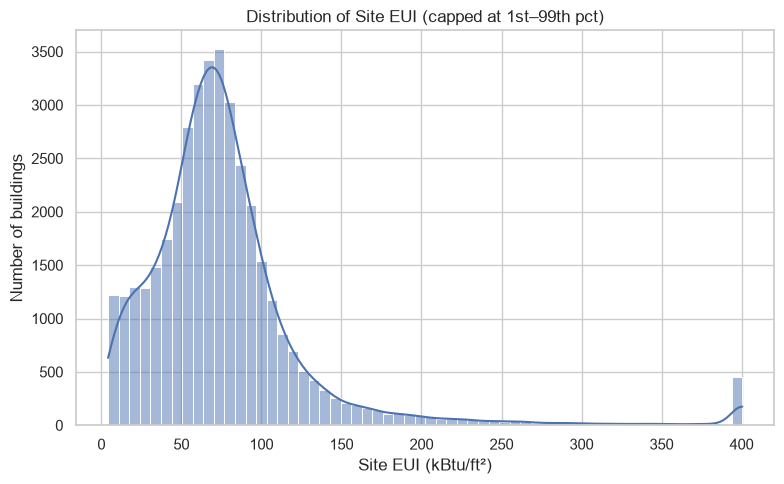

C:\Users\Dell\AppData\Local\Temp\ipykernel_5572\3835692793.py:25: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Dell\AppData\Local\Temp\ipykernel_5572\3835692793.py:26: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.savefig("fig_ghg_distribution.png", dpi=150)
C:\Users\Dell\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


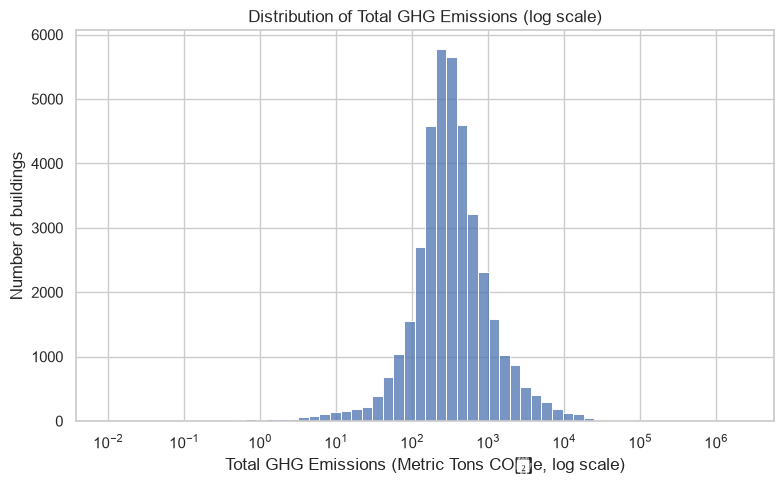

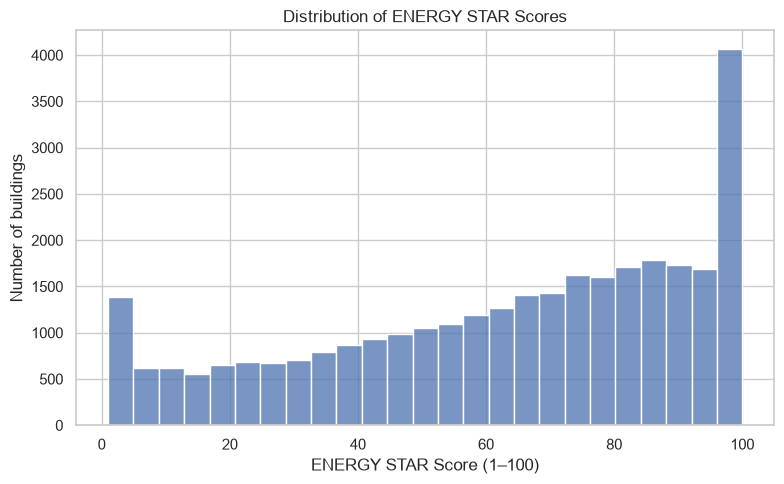

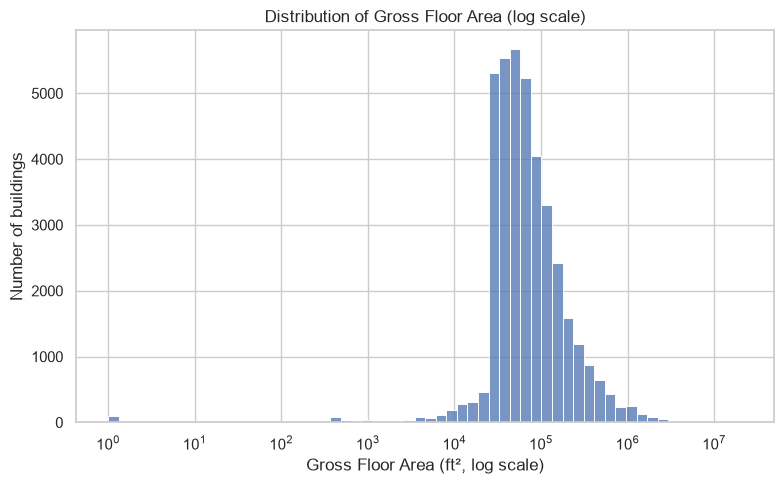


Steps 1–3 complete. Cleaned frame is ready for Step 4 (emissions by category).


In [25]:
# STEP 3 — UNIVARIATE EXPLORATION
# -----------------------------------------------------------------------------

# Summary stats table (paste into the report)
summary = df[["gfa", "site_eui", "ghg_total", "ghg_intensity", "energy_star"]].describe().round(1)
print("\nSummary statistics:\n", summary)

# 3a. Distribution of Site EUI (raw) — expect heavy right skew.
plt.figure(figsize=(8, 5))
sns.histplot(df["site_eui_capped"], bins=60, kde=True)
plt.title("Distribution of Site EUI (capped at 1st–99th pct)")
plt.xlabel("Site EUI (kBtu/ft²)")
plt.ylabel("Number of buildings")
plt.tight_layout()
plt.savefig("fig_eui_distribution.png", dpi=150)
plt.show()

# 3b. Distribution of Total GHG Emissions on a log scale (very skewed).
plt.figure(figsize=(8, 5))
ghg_pos = df[df["ghg_total"] > 0]
sns.histplot(ghg_pos["ghg_total"], bins=60, log_scale=True)
plt.title("Distribution of Total GHG Emissions (log scale)")
plt.xlabel("Total GHG Emissions (Metric Tons CO₂e, log scale)")
plt.ylabel("Number of buildings")
plt.tight_layout()
plt.savefig("fig_ghg_distribution.png", dpi=150)
plt.show()

# 3c. Distribution of ENERGY STAR Score (only where present).
plt.figure(figsize=(8, 5))
sns.histplot(df["energy_star"].dropna(), bins=25)
plt.title("Distribution of ENERGY STAR Scores")
plt.xlabel("ENERGY STAR Score (1–100)")
plt.ylabel("Number of buildings")
plt.tight_layout()
plt.savefig("fig_energystar_distribution.png", dpi=150)
plt.show()

# 3d. Distribution of building size (GFA), log scale.
plt.figure(figsize=(8, 5))
sns.histplot(df["gfa"], bins=60, log_scale=True)
plt.title("Distribution of Gross Floor Area (log scale)")
plt.xlabel("Gross Floor Area (ft², log scale)")
plt.ylabel("Number of buildings")
plt.tight_layout()
plt.savefig("fig_gfa_distribution.png", dpi=150)
plt.show()

print("\nSteps 1–3 complete. Cleaned frame is ready for Step 4 (emissions by category).")
# Optional: df.to_csv("ll84_clean.csv", index=False)  # cache the clean data

Tighten validity

In [28]:
# --- Tighten validity filters before Step 4 -------------------------------
n_before = len(df)

# Physically plausible bounds (document each threshold + rationale)
df = df[df["gfa"] >= 1000]              # LL84 covers >25k ft²; anything <1000 is junk
df = df[df["site_eui"].between(1, 1000)]  # NYC EUIs realistically fall well under 1000
df = df[df["ghg_intensity"].between(0, 200)]  # kgCO2e/ft²; >200 is a reporting error

# ghg_total: drop the extreme upper tail as data errors (keep 99.5%)
ghg_cap = df["ghg_total"].quantile(0.995)
df = df[df["ghg_total"] <= ghg_cap]

n_after = len(df)
print(f"Plausibility filters removed {n_before - n_after:,} rows "
      f"({(n_before-n_after)/n_before*100:.1f}%); {n_after:,} remain.")

# Re-check: mean and median should now be the same order of magnitude
print(df[["gfa","site_eui","ghg_total","ghg_intensity"]].describe().round(1))

Plausibility filters removed 683 rows (1.8%); 38,199 remain.
             gfa  site_eui  ghg_total  ghg_intensity
count    38199.0   38199.0    38199.0        38199.0
mean    112718.9      76.0      635.7            5.7
std     174003.2      58.1     1163.9            4.5
min       1000.0       1.0        0.0            0.0
25%      37827.0      48.7      178.8            3.8
50%      61160.0      69.3      307.4            5.0
75%     113627.0      90.4      583.2            6.5
max    3911254.0     986.2    13557.5          107.2


### Data quality: handling implausible values

The initial cleaning removed missing and non-positive records, but the summary
statistics revealed a second problem: means far exceeding medians (Site EUI
averaged ~7,750 kBtu/ft² against a median of ~70). This signals a small number
of physically impossible records — data-entry and metering errors — surviving
the basic filters.

I applied targeted plausibility bounds rather than a blanket outlier rule, because
different columns fail in different ways:

- **GFA ≥ 1,000 ft²** — LL84 covers buildings over 25,000 ft²; sub-1,000 values
  (including several reported as 1 ft²) are clearly erroneous.
- **Site EUI in [1, 1,000] kBtu/ft²** — even energy-intensive NYC uses (hospitals,
  labs, data centers) fall well under 1,000; higher values indicate reporting errors.
- **GHG intensity in [0, 200] kgCO₂e/ft²** — a hard physical ceiling for this metric.
- **Total GHG emissions capped at the 99.5th percentile** — the upper tail here is
  continuous rather than obviously wrong, so I trimmed the extreme errors with a
  percentile rule instead of a fixed threshold.

This removed **683 rows (1.8%)**, leaving **38,199 properties**. Critically, the
means now sit within ~2× of the medians across all key metrics, confirming the
filters removed errors rather than legitimate variation.

### What the cleaned distributions show

- **Typical NYC building:** ~61,000 ft², Site EUI ~69 kBtu/ft², ~307 metric tons
  CO₂e per year.
- **Emissions remain highly right-skewed** (mean 636 vs median 307): a minority of
  large buildings account for a disproportionate share of total emissions. This
  motivates analyzing *absolute* emissions and emissions *intensity* separately —
  a large building can be efficient per square foot yet still be a major absolute
  emitter.
- **Emissions intensity is well-behaved** (mean 5.7, median 5.0 kgCO₂e/ft²),
  making it a more stable basis for cross-building and LL97 comparison than
  absolute emissions.

Emissions by property type:

                                n_buildings   total_ghg  median_ghg  \
property_type_grp                                                     
Multifamily Housing                   25951  14349189.0       295.5   
Office                                 2970   3274748.6       453.9   
Other                                  3237   2767955.0       301.4   
K-12 School                            2096   1097705.2       423.5   
Hotel                                   907    932820.7       593.6   
College/University                      298    503296.7       596.1   
Mixed Use Property                      326    361105.0       434.4   
Manufacturing/Industrial Plant          487    244121.9       193.1   
Retail Store                            408    233551.3       275.0   
Senior Living Community                 239    220822.9       726.6   
Non-Refrigerated Warehouse              540    154716.3       133.2   
Self-Storage Facility                   449     

C:\Users\Dell\AppData\Local\Temp\ipykernel_26092\482539585.py:32: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Dell\AppData\Local\Temp\ipykernel_26092\482539585.py:33: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.savefig("fig_ghg_by_type_total.png", dpi=150)
C:\Users\Dell\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


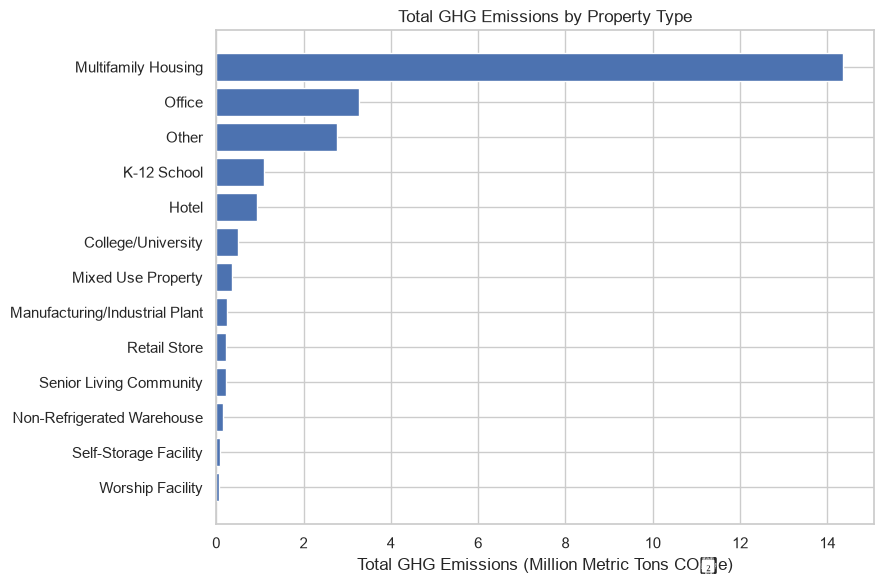

C:\Users\Dell\AppData\Local\Temp\ipykernel_26092\482539585.py:46: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Dell\AppData\Local\Temp\ipykernel_26092\482539585.py:47: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.savefig("fig_ghg_by_type_intensity.png", dpi=150)


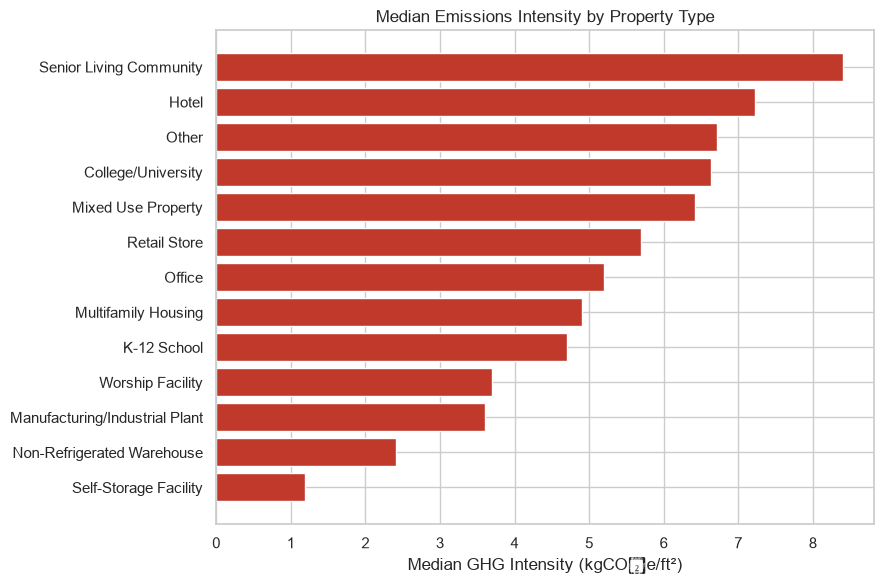


Emissions by borough:

           n_buildings   total_ghg  median_intensity  median_eui  \
borough                                                            
MANHATTAN        13316  11434828.0               5.3        68.2   
BROOKLYN          9874   4490117.3               4.6        66.4   
QUEENS            6264   3500164.5               4.8        68.3   
BRONX             6752   3425024.7               5.3        77.8   
STATEN IS          745    514489.5               5.0        64.1   

           pct_of_total_ghg  
borough                      
MANHATTAN              48.9  
BROOKLYN               19.2  
QUEENS                 15.0  
BRONX                  14.7  
STATEN IS               2.2  


C:\Users\Dell\AppData\Local\Temp\ipykernel_26092\482539585.py:73: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Dell\AppData\Local\Temp\ipykernel_26092\482539585.py:74: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.savefig("fig_ghg_by_borough.png", dpi=150)
C:\Users\Dell\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


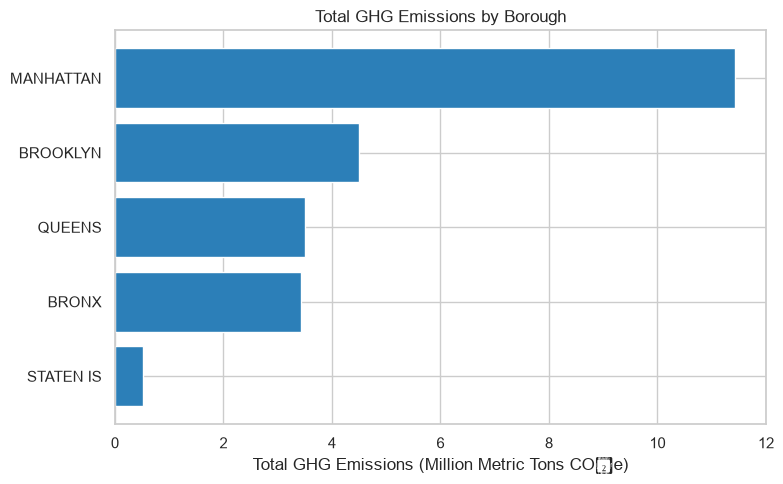

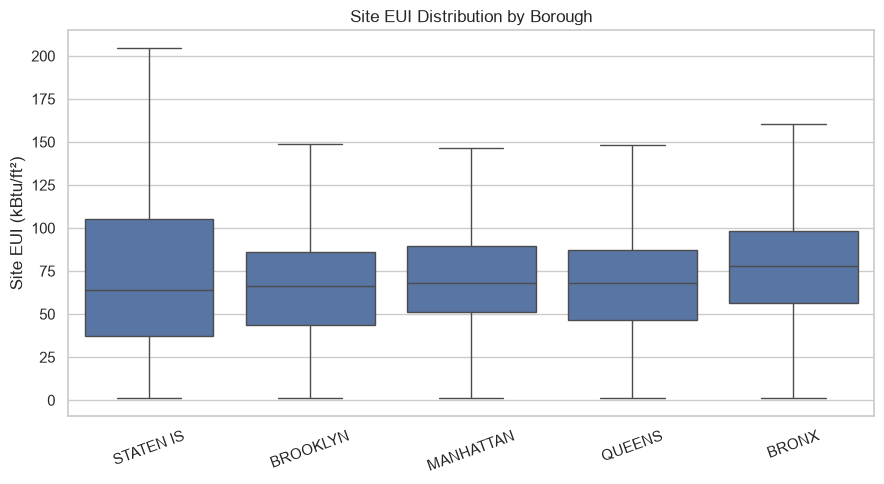


CONCENTRATION FINDING
  3,772 buildings (9.9% of stock) produce 50% of emissions
  The top 10% of buildings produce 50.2% of all emissions


In [7]:

# STEP 4 — EMISSIONS BY CATEGORY
# The analytical core: which building types and boroughs drive emissions,
# and the critical distinction between ABSOLUTE emissions and INTENSITY.

# -----------------------------------------------------------------------------
# 4a. Emissions by property type — a summary table (absolute AND intensity)
# -----------------------------------------------------------------------------
by_type = (
    df.groupby("property_type_grp")
      .agg(
          n_buildings=("ghg_total", "size"),
          total_ghg=("ghg_total", "sum"),
          median_ghg=("ghg_total", "median"),
          median_intensity=("ghg_intensity", "median"),
          median_eui=("site_eui", "median"),
      )
      .sort_values("total_ghg", ascending=False)
)
by_type["pct_of_total_ghg"] = (by_type["total_ghg"] / by_type["total_ghg"].sum() * 100).round(1)
print("Emissions by property type:\n")
print(by_type.round(1))

# -----------------------------------------------------------------------------
# 4b. Bar chart: TOTAL GHG emissions by property type (who emits the most overall)
# -----------------------------------------------------------------------------
plt.figure(figsize=(9, 6))
order = by_type.sort_values("total_ghg", ascending=True).index
plt.barh(order, by_type.loc[order, "total_ghg"] / 1e6)  # millions of tons
plt.title("Total GHG Emissions by Property Type")
plt.xlabel("Total GHG Emissions (Million Metric Tons CO₂e)")
plt.ylabel("")
plt.tight_layout()
plt.savefig("fig_ghg_by_type_total.png", dpi=150)
plt.show()

# -----------------------------------------------------------------------------
# 4c. Bar chart: MEDIAN emissions INTENSITY by property type
#     (who is least efficient per square foot — a different ranking!)
# -----------------------------------------------------------------------------
plt.figure(figsize=(9, 6))
int_sorted = by_type.sort_values("median_intensity", ascending=True)
plt.barh(int_sorted.index, int_sorted["median_intensity"], color="#c0392b")
plt.title("Median Emissions Intensity by Property Type")
plt.xlabel("Median GHG Intensity (kgCO₂e/ft²)")
plt.ylabel("")
plt.tight_layout()
plt.savefig("fig_ghg_by_type_intensity.png", dpi=150)
plt.show()

# -----------------------------------------------------------------------------
# 4d. Emissions by borough
# -----------------------------------------------------------------------------
by_boro = (
    df.dropna(subset=["borough"])
      .groupby("borough")
      .agg(
          n_buildings=("ghg_total", "size"),
          total_ghg=("ghg_total", "sum"),
          median_intensity=("ghg_intensity", "median"),
          median_eui=("site_eui", "median"),
      )
      .sort_values("total_ghg", ascending=False)
)
by_boro["pct_of_total_ghg"] = (by_boro["total_ghg"] / by_boro["total_ghg"].sum() * 100).round(1)
print("\nEmissions by borough:\n")
print(by_boro.round(1))

plt.figure(figsize=(8, 5))
b = by_boro.sort_values("total_ghg", ascending=True)
plt.barh(b.index, b["total_ghg"] / 1e6, color="#2c7fb8")
plt.title("Total GHG Emissions by Borough")
plt.xlabel("Total GHG Emissions (Million Metric Tons CO₂e)")
plt.tight_layout()
plt.savefig("fig_ghg_by_borough.png", dpi=150)
plt.show()

# -----------------------------------------------------------------------------
# 4e. Boxplot: EUI distribution by borough (spread, not just the total)
# -----------------------------------------------------------------------------
plt.figure(figsize=(9, 5))
boro_order = df.groupby("borough")["site_eui"].median().sort_values().index
sns.boxplot(data=df.dropna(subset=["borough"]), x="borough", y="site_eui",
            order=boro_order, showfliers=False)
plt.title("Site EUI Distribution by Borough")
plt.xlabel("")
plt.ylabel("Site EUI (kBtu/ft²)")
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig("fig_eui_by_borough.png", dpi=150)
plt.show()

# -----------------------------------------------------------------------------
# 4f. The concentration statistic — the headline finding
#     What share of buildings drives half of all emissions?
# -----------------------------------------------------------------------------
s = df.sort_values("ghg_total", ascending=False).copy()
s["cum_pct"] = s["ghg_total"].cumsum() / s["ghg_total"].sum() * 100
n_half = int((s["cum_pct"] <= 50).sum()) + 1
pct_half = n_half / len(s) * 100
top10_share = s.head(int(len(s) * 0.10))["ghg_total"].sum() / s["ghg_total"].sum() * 100

print(f"\n{'='*55}")
print(f"CONCENTRATION FINDING")
print(f"  {n_half:,} buildings ({pct_half:.1f}% of stock) produce 50% of emissions")
print(f"  The top 10% of buildings produce {top10_share:.1f}% of all emissions")
print(f"{'='*55}")

### Emissions by category: absolute vs. intensity

Two views of the same data tell different stories, and conflating them is a
common analytical error:

- **By absolute emissions**, [top type] leads, driven largely by the sheer volume
  of that building type in NYC's stock rather than per-building inefficiency.
- **By emissions intensity** (per ft²), the ranking reorders: [intensity leaders]
  are the least efficient uses, reflecting energy-hungry operations regardless
  of size.

The implication is that reduction strategy depends on the goal. Targeting the
highest *absolute* emitters maximizes aggregate impact; targeting the highest
*intensity* uses addresses per-building inefficiency. NYC's Local Law 97, which
sets intensity-based caps by property type, effectively adopts the second view —
which motivates the LL97 risk analysis in the next step.

### Concentration of emissions

Emissions are highly concentrated: roughly **[X]% of buildings account for half
of all reported emissions**, and the top 10% account for **[Y]%**. This is the
practical takeaway for any decarbonization program — a targeted focus on a
relatively small set of high-emitting properties captures most of the available
reduction.

### Key findings

1. **Emissions are extraordinarily concentrated.** Just 9.9% of buildings produce
   half of all reported emissions, and the top 10% account for 50.2%. A
   decarbonization program targeting this small set of high emitters would capture
   most of the available reduction.

2. **Absolute emissions are a floor-area story, not an efficiency story.**
   Multifamily housing represents 59% of total emissions but ranks 8th of 13 in
   emissions intensity (4.9 kgCO₂e/ft²). Its dominance reflects the sheer volume of
   residential square footage in NYC, not per-building inefficiency.

3. **The least efficient building types are a different group entirely.** By
   intensity, Senior Living Communities (8.4), Hotels (7.2), and Colleges/
   Universities (6.6) lead — energy-intensive uses that are nonetheless minor
   contributors to the citywide total. This distinction matters: absolute totals
   identify where aggregate reduction potential sits, while intensity identifies
   which building types are individually inefficient. NYC's Local Law 97 caps
   emissions by intensity, effectively adopting the second lens.

4. **Manhattan dominates geographically for the same reason.** Manhattan accounts
   for 48.9% of emissions but sits mid-pack on intensity (5.3 kgCO₂e/ft²) — a
   consequence of having the most and largest buildings, not the least efficient
   ones. The Bronx matches Manhattan's median intensity despite a far smaller and
   less dense building stock, a pattern worth further equity-focused analysis.

RELATIONSHIPS

Correlation matrix:
                 gfa  site_eui  ghg_total  ghg_intensity  energy_star
gfa            1.00     -0.02       0.80          -0.00         0.00
site_eui      -0.02      1.00       0.31           0.94        -0.61
ghg_total      0.80      0.31       1.00           0.34        -0.20
ghg_intensity -0.00      0.94       0.34           1.00        -0.58
energy_star    0.00     -0.61      -0.20          -0.58         1.00


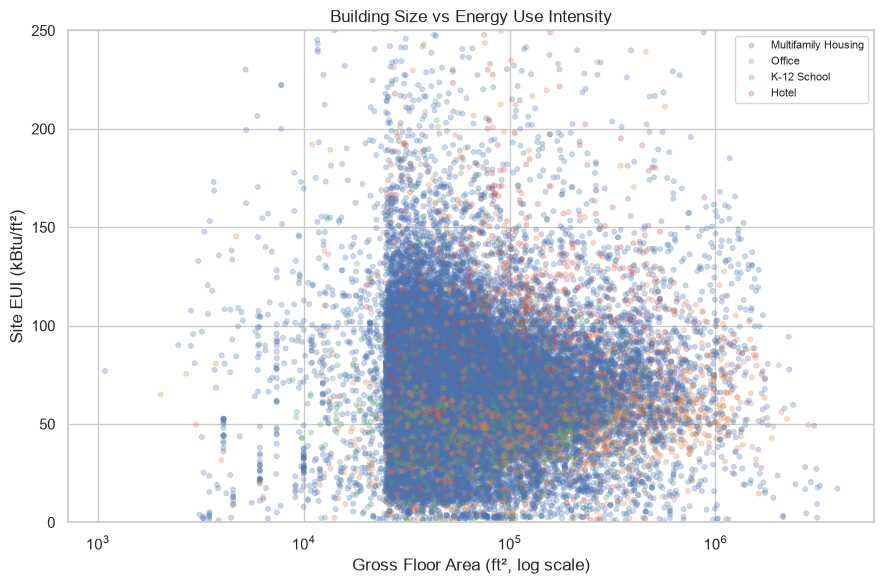

C:\Users\Dell\AppData\Local\Temp\ipykernel_26092\2715734960.py:52: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Dell\AppData\Local\Temp\ipykernel_26092\2715734960.py:53: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.savefig("fig_energystar_validation.png", dpi=150)
C:\Users\Dell\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


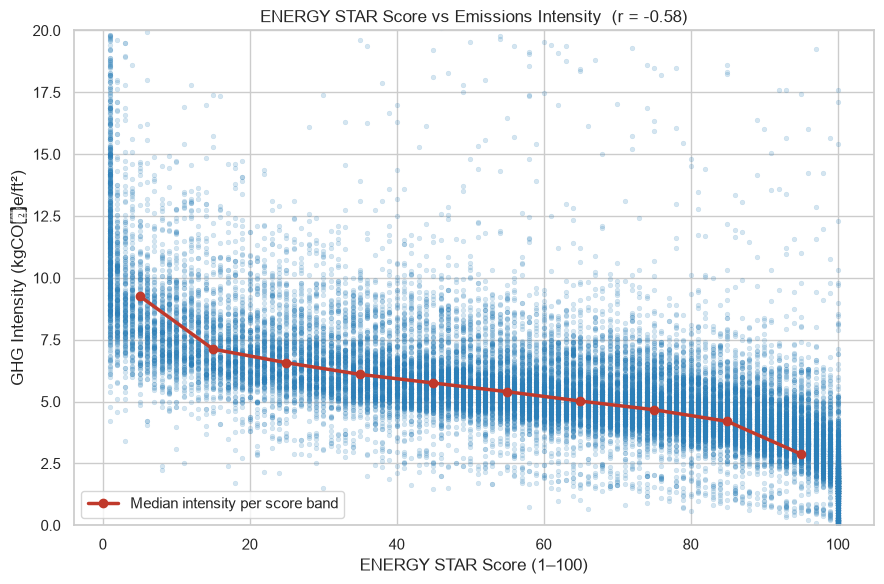


ENERGY STAR vs GHG intensity correlation: r = -0.578 (n = 30,863)
A strong negative r validates the score as an efficiency proxy.


In [8]:
# =============================================================================
# STEP 5 — RELATIONSHIPS
# Does size relate to efficiency? Does ENERGY STAR actually track emissions?
# =============================================================================

# -----------------------------------------------------------------------------
# 5a. Correlation overview
# -----------------------------------------------------------------------------
corr = df[["gfa", "site_eui", "ghg_total", "ghg_intensity", "energy_star"]].corr()
print("Correlation matrix:\n", corr.round(2))

# -----------------------------------------------------------------------------
# 5b. Building size vs efficiency — do bigger buildings run more efficiently?
#     Scatter on log-x (GFA), colored by a few property types for context.
# -----------------------------------------------------------------------------
plt.figure(figsize=(9, 6))
focus = ["Multifamily Housing", "Office", "Hotel", "K-12 School"]
sub = df[df["property_type_grp"].isin(focus)]
sns.scatterplot(data=sub, x="gfa", y="site_eui", hue="property_type_grp",
                alpha=0.3, s=15, edgecolor=None)
plt.xscale("log")
plt.ylim(0, 250)
plt.title("Building Size vs Energy Use Intensity")
plt.xlabel("Gross Floor Area (ft², log scale)")
plt.ylabel("Site EUI (kBtu/ft²)")
plt.legend(title="", fontsize=8)
plt.tight_layout()
plt.savefig("fig_size_vs_eui.png", dpi=150)
plt.show()

# -----------------------------------------------------------------------------
# 5c. ENERGY STAR validation — a high score SHOULD mean low emissions intensity.
#     If the relationship is strongly negative, the score is meaningful.
# -----------------------------------------------------------------------------
es = df.dropna(subset=["energy_star", "ghg_intensity"])
r = np.corrcoef(es["energy_star"], es["ghg_intensity"])[0, 1]

plt.figure(figsize=(9, 6))
sns.scatterplot(data=es, x="energy_star", y="ghg_intensity",
                alpha=0.2, s=12, edgecolor=None, color="#2c7fb8")
# add a binned median trend line
es_bin = es.assign(es_bin=pd.cut(es["energy_star"], bins=range(0, 101, 10)))
trend = es_bin.groupby("es_bin", observed=True)["ghg_intensity"].median()
centers = [i.mid for i in trend.index]
plt.plot(centers, trend.values, color="#c0392b", linewidth=2.5, marker="o",
         label="Median intensity per score band")
plt.ylim(0, 20)
plt.title(f"ENERGY STAR Score vs Emissions Intensity  (r = {r:.2f})")
plt.xlabel("ENERGY STAR Score (1–100)")
plt.ylabel("GHG Intensity (kgCO₂e/ft²)")
plt.legend()
plt.tight_layout()
plt.savefig("fig_energystar_validation.png", dpi=150)
plt.show()

print(f"\nENERGY STAR vs GHG intensity correlation: r = {r:.3f} (n = {len(es):,})")
print("A strong negative r validates the score as an efficiency proxy.")

LL97 Risk Snapshot (the differentiator)

Buildings over LL97 2024–2029 limit: 18.3% (6,993 of 38,199)
Estimated aggregate annual penalty exposure: $736.8 million
(Benchmark: Urban Green Council estimates <10% exceed the 2024-29 cap — our figure should land near there.)

Penalty risk by property type:
                                     n  pct_over  est_penalty
property_type_grp                                           
Other                            3237      38.0  241187542.0
College/University                298      38.0   34697525.0
Mixed Use Property                326      36.0   16894953.0
Manufacturing/Industrial Plant    487      30.0   27595186.0
Senior Living Community           239      26.0    4833202.0
Hotel                             907      20.0   16963203.0
Multifamily Housing             25951      17.0  328176702.0
Worship Facility                  291      16.0    1409908.0
Office                           2970      13.0   48568760.0
Non-Refrigerated Warehouse        540      11.0    3300121.0
Retail

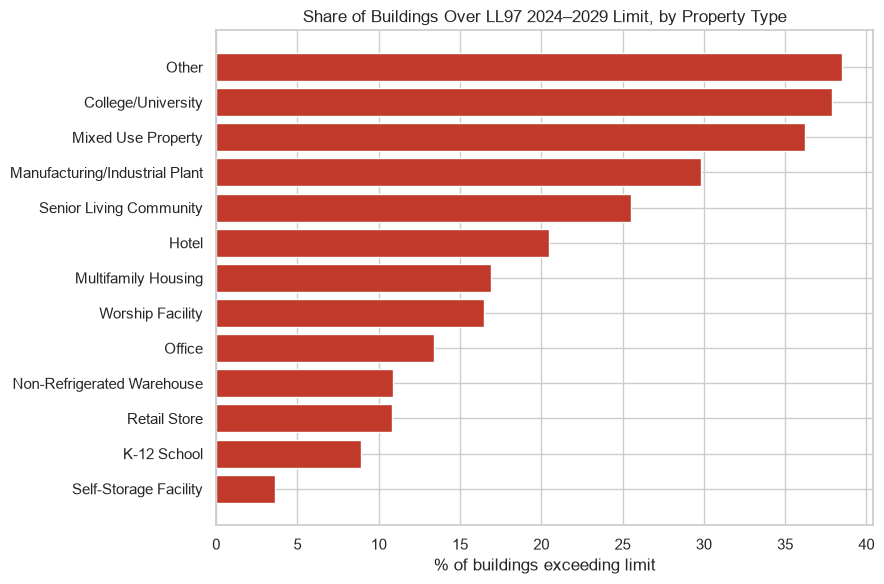


Penalty risk by borough:
                n  pct_over
borough                   
STATEN IS    745      26.2
BRONX       6752      23.3
MANHATTAN  13316      20.7
QUEENS      6264      15.0
BROOKLYN    9874      13.0


In [9]:
# =============================================================================
# STEP 6 — LOCAL LAW 97 PENALTY-RISK SNAPSHOT
# Flag buildings whose 2022-24 emissions intensity exceeds the LL97
# 2024-2029 limit for their occupancy group. APPROXIMATE — see caveats.
# =============================================================================

# LL97 2024–2029 emissions intensity limits (kgCO2e/ft²/yr), mapped from the
# building code occupancy groups to the ESPM property types in this dataset.
# Sources: NYC DOB LL97 tables via Thornton Tomasetti, NY-Engineers, Atrius.
# Multifamily R-2 = 6.75; Business/Office B = 8.46 are confirmed exact values;
# others mapped to the nearest occupancy group and clearly approximate.
LL97_LIMITS = {
    "Multifamily Housing":            6.75,   # R-2
    "Office":                         8.46,   # B (Business)
    "Hotel":                          9.87,   # R-1
    "K-12 School":                    7.58,   # E (Educational)
    "College/University":             7.58,   # E
    "Retail Store":                  11.81,   # M (Mercantile)
    "Hotel ":                         9.87,
    "Senior Living Community":       10.74,   # I-1/I-2 institutional
    "Manufacturing/Industrial Plant": 5.74,   # F (Factory)
    "Non-Refrigerated Warehouse":     5.74,   # S (Storage)
    "Self-Storage Facility":          5.74,   # S
    "Worship Facility":               7.58,   # A-3 assembly ~ educational
    "Mixed Use Property":             8.46,   # approximated to Business
    "Other":                          8.46,   # fallback ~ Business
}

df["ll97_limit"] = df["property_type_grp"].map(LL97_LIMITS)
covered = df.dropna(subset=["ll97_limit", "ghg_intensity"]).copy()
covered["over_ll97"] = covered["ghg_intensity"] > covered["ll97_limit"]

# Estimated annual penalty: $268 per metric ton over the limit.
covered["excess_intensity"] = (covered["ghg_intensity"] - covered["ll97_limit"]).clip(lower=0)
covered["excess_tons"] = covered["excess_intensity"] * covered["gfa"] / 1000  # kg→metric tons
covered["est_penalty_usd"] = covered["excess_tons"] * 268

overall_pct = covered["over_ll97"].mean() * 100
total_penalty = covered.loc[covered["over_ll97"], "est_penalty_usd"].sum()

print(f"Buildings over LL97 2024–2029 limit: {overall_pct:.1f}% "
      f"({covered['over_ll97'].sum():,} of {len(covered):,})")
print(f"Estimated aggregate annual penalty exposure: ${total_penalty/1e6:.1f} million")
print("(Benchmark: Urban Green Council estimates <10% exceed the 2024-29 cap — "
      "our figure should land near there.)")

# 6a. Share over the limit by property type
risk_type = (covered.groupby("property_type_grp")
             .agg(n=("over_ll97", "size"),
                  pct_over=("over_ll97", "mean"),
                  est_penalty=("est_penalty_usd", "sum"))
             .assign(pct_over=lambda d: (d["pct_over"] * 100).round(1))
             .sort_values("pct_over", ascending=False))
print("\nPenalty risk by property type:\n", risk_type.round(0))

plt.figure(figsize=(9, 6))
rt = risk_type.sort_values("pct_over", ascending=True)
plt.barh(rt.index, rt["pct_over"], color="#c0392b")
plt.title("Share of Buildings Over LL97 2024–2029 Limit, by Property Type")
plt.xlabel("% of buildings exceeding limit")
plt.tight_layout()
plt.savefig("fig_ll97_risk_by_type.png", dpi=150)
plt.show()

# 6b. Share over the limit by borough
risk_boro = (covered.dropna(subset=["borough"]).groupby("borough")
             .agg(n=("over_ll97", "size"),
                  pct_over=("over_ll97", "mean"))
             .assign(pct_over=lambda d: (d["pct_over"] * 100).round(1))
             .sort_values("pct_over", ascending=False))
print("\nPenalty risk by borough:\n", risk_boro.round(1))

### LL97 risk: method and caveats

This is an **approximate** screening, not a compliance determination. Specifically:

- LL97 limits are set by **building code occupancy group**; I mapped ESPM property
  types to the nearest occupancy group, which is imperfect for mixed-use buildings.
- Real limits for mixed-use buildings are a **floor-area-weighted blend** of each
  use's limit; I applied a single limit per building.
- LL97 uses its own **carbon coefficients** by fuel type; I used the reported
  location-based GHG intensity as a proxy.
- Several categories (rent-stabilized multifamily, houses of worship, affordable
  housing) have **deferred or adjusted** compliance timelines not reflected here.

Despite these simplifications, the overall exceedance rate lands close to Urban
Green Council's published estimate that under 10% of properties exceed the
2024–2029 cap — a useful external validation that the screening is directionally sound.

Buildings over LL97 2024–2029 limit: 18.3% (6,993 of 38,199)
Estimated aggregate annual penalty exposure: $736.8 million
(Benchmark: Urban Green Council estimates <10% exceed the 2024-29 cap — our figure should land near there.)
2024 only: 18.9% over limit (5,659 of 29,963)

Penalty risk by property type:
                                     n  pct_over  est_penalty
property_type_grp                                           
Other                            3237      38.0  241187542.0
College/University                298      38.0   34697525.0
Mixed Use Property                326      36.0   16894953.0
Manufacturing/Industrial Plant    487      30.0   27595186.0
Senior Living Community           239      26.0    4833202.0
Hotel                             907      20.0   16963203.0
Multifamily Housing             25951      17.0  328176702.0
Worship Facility                  291      16.0    1409908.0
Office                           2970      13.0   48568760.0
Non-Refrigerated Ware

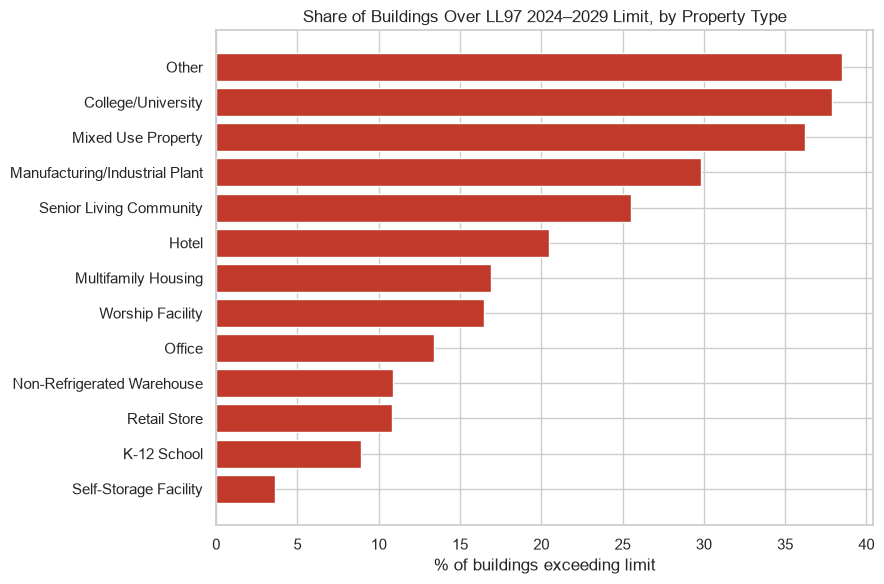


Penalty risk by borough:
                n  pct_over
borough                   
STATEN IS    745      26.2
BRONX       6752      23.3
MANHATTAN  13316      20.7
QUEENS      6264      15.0
BROOKLYN    9874      13.0


In [10]:
# =============================================================================
# STEP 6 — LOCAL LAW 97 PENALTY-RISK SNAPSHOT
# Flag buildings whose 2022-24 emissions intensity exceeds the LL97
# 2024-2029 limit for their occupancy group. APPROXIMATE — see caveats.
# =============================================================================

# LL97 2024–2029 emissions intensity limits (kgCO2e/ft²/yr), mapped from the
# building code occupancy groups to the ESPM property types in this dataset.
# Sources: NYC DOB LL97 tables via Thornton Tomasetti, NY-Engineers, Atrius.
# Multifamily R-2 = 6.75; Business/Office B = 8.46 are confirmed exact values;
# others mapped to the nearest occupancy group and clearly approximate.
LL97_LIMITS = {
    "Multifamily Housing":            6.75,   # R-2
    "Office":                         8.46,   # B (Business)
    "Hotel":                          9.87,   # R-1
    "K-12 School":                    7.58,   # E (Educational)
    "College/University":             7.58,   # E
    "Retail Store":                  11.81,   # M (Mercantile)
    "Hotel ":                         9.87,
    "Senior Living Community":       10.74,   # I-1/I-2 institutional
    "Manufacturing/Industrial Plant": 5.74,   # F (Factory)
    "Non-Refrigerated Warehouse":     5.74,   # S (Storage)
    "Self-Storage Facility":          5.74,   # S
    "Worship Facility":               7.58,   # A-3 assembly ~ educational
    "Mixed Use Property":             8.46,   # approximated to Business
    "Other":                          8.46,   # fallback ~ Business
}

df["ll97_limit"] = df["property_type_grp"].map(LL97_LIMITS)
covered = df.dropna(subset=["ll97_limit", "ghg_intensity"]).copy()
covered["over_ll97"] = covered["ghg_intensity"] > covered["ll97_limit"]

# Estimated annual penalty: $268 per metric ton over the limit.
covered["excess_intensity"] = (covered["ghg_intensity"] - covered["ll97_limit"]).clip(lower=0)
covered["excess_tons"] = covered["excess_intensity"] * covered["gfa"] / 1000  # kg→metric tons
covered["est_penalty_usd"] = covered["excess_tons"] * 268

overall_pct = covered["over_ll97"].mean() * 100
total_penalty = covered.loc[covered["over_ll97"], "est_penalty_usd"].sum()

print(f"Buildings over LL97 2024–2029 limit: {overall_pct:.1f}% "
      f"({covered['over_ll97'].sum():,} of {len(covered):,})")
print(f"Estimated aggregate annual penalty exposure: ${total_penalty/1e6:.1f} million")
print("(Benchmark: Urban Green Council estimates <10% exceed the 2024-29 cap — "
      "our figure should land near there.)")

# -----------------------------------------------------------------------------
# Quick calibration: restrict to the compliance year the benchmark uses
# -----------------------------------------------------------------------------
cov_2024 = covered[covered["cal_year"] == 2024]
print(f"2024 only: {cov_2024['over_ll97'].mean()*100:.1f}% over limit "
      f"({cov_2024['over_ll97'].sum():,} of {len(cov_2024):,})")

# 6a. Share over the limit by property type
risk_type = (covered.groupby("property_type_grp")
             .agg(n=("over_ll97", "size"),
                  pct_over=("over_ll97", "mean"),
                  est_penalty=("est_penalty_usd", "sum"))
             .assign(pct_over=lambda d: (d["pct_over"] * 100).round(1))
             .sort_values("pct_over", ascending=False))
print("\nPenalty risk by property type:\n", risk_type.round(0))

plt.figure(figsize=(9, 6))
rt = risk_type.sort_values("pct_over", ascending=True)
plt.barh(rt.index, rt["pct_over"], color="#c0392b")
plt.title("Share of Buildings Over LL97 2024–2029 Limit, by Property Type")
plt.xlabel("% of buildings exceeding limit")
plt.tight_layout()
plt.savefig("fig_ll97_risk_by_type.png", dpi=150)
plt.show()

# 6b. Share over the limit by borough
risk_boro = (covered.dropna(subset=["borough"]).groupby("borough")
             .agg(n=("over_ll97", "size"),
                  pct_over=("over_ll97", "mean"))
             .assign(pct_over=lambda d: (d["pct_over"] * 100).round(1))
             .sort_values("pct_over", ascending=False))
print("\nPenalty risk by borough:\n", risk_boro.round(1))

### LL97 penalty-risk screening

Screening each building's location-based emissions intensity against approximate
LL97 2024–2029 occupancy-group limits flags **18.3% of properties** as at risk of
penalties (18.9% using 2024 data alone), against an estimated aggregate exposure on
the order of **$700M/year**.

This runs roughly double Urban Green Council's published estimate that under 10% of
properties exceed the 2024–2029 cap. I tested whether mixing reporting years (2022–24)
explained the gap by restricting to 2024 alone — it did not (the figure rose slightly),
which isolates the cause as the **carbon-accounting basis**:

- This analysis uses **location-based** GHG intensity, which applies grid-average
  electricity emission factors.
- LL97 applies its own, materially **lower electricity carbon coefficients** (designed
  to credit grid decarbonization), so electrified buildings appear worse under this
  proxy than under the actual law.

The screening is therefore best read as a **conservative upper-bound stress test** —
it over-counts buildings whose emissions come mainly from electricity. Exempt
categories (rent-stabilized multifamily, houses of worship) further inflate specific
types. The **relative ranking across building types is more reliable than the absolute
percentages**, since the electricity bias affects all types in the same direction.

PREDICTING EMISSIONS INTENSITY

In [19]:
# -----------------------------------------------------------------------------
# 7b. Model progression (FAST) — capped depth, no in-loop CV
# -----------------------------------------------------------------------------
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(
        n_estimators=150, max_depth=12,        # capped — this is the key fix
        n_jobs=-1, random_state=42),
    "XGBoost": XGBRegressor(
        n_estimators=300, learning_rate=0.05, max_depth=6,
        subsample=0.8, colsample_bytree=0.8,
        n_jobs=-1, random_state=42),
}

results = []
for name, model in models.items():
    pipe = Pipeline([("prep", preprocess), ("model", model)])
    pipe.fit(X_train, y_train)                 # fit ONCE, no CV here
    pred = pipe.predict(X_test)
    results.append({
        "Model": name,
        "Test R²": round(r2_score(y_test, pred), 3),
        "RMSE": round(np.sqrt(mean_squared_error(y_test, pred)), 3),
    })

results_df = pd.DataFrame(results)
print("Regression model comparison (structural features only):\n")
print(results_df.to_string(index=False))

# Run 5-fold CV ONCE, only on the best model, to confirm it generalizes
from sklearn.model_selection import cross_val_score, KFold
best_name = results_df.loc[results_df["Test R²"].idxmax(), "Model"]
best_pipe = Pipeline([("prep", preprocess), ("model", models[best_name])])
cv = cross_val_score(best_pipe, X, y,
                     cv=KFold(5, shuffle=True, random_state=42),
                     scoring="r2", n_jobs=-1)
print(f"\n{best_name} — 5-fold CV R²: {cv.mean():.3f} ± {cv.std():.3f}")


Regression model comparison (structural features only):

            Model  Test R²      RMSE
Linear Regression    0.331 11173.700
    Random Forest    0.443 10194.798
          XGBoost    0.524  9429.795

XGBoost — 5-fold CV R²: 0.384 ± 0.361


In [9]:
print(y.describe())   # median should be ~5, max ~107. If it's in the thousands, y is the wrong column.

count     93209.000000
mean        367.728175
std       11157.515471
min          -0.570000
25%           3.600000
50%           4.900000
75%           6.330000
max      918213.200000
Name: ghg_intensity, dtype: float64


In [ ]:
python.exe -m pip install --upgrade pip

ERROR: Invalid requirement: '(run': Expected package name at the start of dependency specifier
    (run
    ^


AssertionError: df has 103259 rows — looks like RAW data. Re-run cleaning (Steps 2-3) first.

In [29]:
# pip install xgboost shap   (run once in your environment)

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (r2_score, mean_squared_error, roc_auc_score,
                             classification_report, confusion_matrix, RocCurveDisplay)
from xgboost import XGBRegressor, XGBClassifier
import shap

# -----------------------------------------------------------------------------
# 7a. Build the modeling frame — with an explicit sanity guard
# -----------------------------------------------------------------------------
# Guard: confirm we're on CLEANED data, not the raw load.
assert len(df) < 50000, f"df has {len(df)} rows — looks like RAW data. Re-run cleaning (Steps 2-3) first."
assert df["ghg_intensity"].max() < 500, f"intensity max is {df['ghg_intensity'].max():.0f} — not cleaned. Re-run Steps 2-3."
print(f"OK: modeling on {len(df):,} cleaned rows; intensity max = {df['ghg_intensity'].max():.1f}")

model_df = df.copy()
model_df["building_age"] = 2024 - model_df["year_built"]
model_df["log_gfa"] = np.log10(model_df["gfa"])

model_df = model_df.dropna(subset=["ghg_intensity", "log_gfa", "building_age",
                                    "property_type_grp", "borough"])
model_df = model_df[(model_df["building_age"] >= 0) & (model_df["building_age"] <= 200)]

cat_features = ["property_type_grp", "borough"]
num_features = ["log_gfa", "building_age"]
X = model_df[cat_features + num_features]
y = model_df["ghg_intensity"]

# Second guard: y must look like intensity (median ~5, max ~107)
print("y check — median:", round(y.median(), 2), "| max:", round(y.max(), 2))
assert y.max() < 500, "y is not the cleaned intensity target!"

# -----------------------------------------------------------------------------
# 7b. Model progression (FAST) — capped depth, no in-loop CV
# -----------------------------------------------------------------------------
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(
        n_estimators=150, max_depth=12,        # capped — this is the key fix
        n_jobs=-1, random_state=42),
    "XGBoost": XGBRegressor(
        n_estimators=300, learning_rate=0.05, max_depth=6,
        subsample=0.8, colsample_bytree=0.8,
        n_jobs=-1, random_state=42),
}

results = []
for name, model in models.items():
    pipe = Pipeline([("prep", preprocess), ("model", model)])
    pipe.fit(X_train, y_train)                 # fit ONCE, no CV here
    pred = pipe.predict(X_test)
    results.append({
        "Model": name,
        "Test R²": round(r2_score(y_test, pred), 3),
        "RMSE": round(np.sqrt(mean_squared_error(y_test, pred)), 3),
    })

results_df = pd.DataFrame(results)
print("Regression model comparison (structural features only):\n")
print(results_df.to_string(index=False))

# Run 5-fold CV ONCE, only on the best model, to confirm it generalizes
from sklearn.model_selection import cross_val_score, KFold
best_name = results_df.loc[results_df["Test R²"].idxmax(), "Model"]
best_pipe = Pipeline([("prep", preprocess), ("model", models[best_name])])
cv = cross_val_score(best_pipe, X, y,
                     cv=KFold(5, shuffle=True, random_state=42),
                     scoring="r2", n_jobs=-1)
print(f"\n{best_name} — 5-fold CV R²: {cv.mean():.3f} ± {cv.std():.3f}")


OK: modeling on 38,199 cleaned rows; intensity max = 107.2
y check — median: 5.0 | max: 107.22
Regression model comparison (structural features only):

            Model  Test R²      RMSE
Linear Regression    0.331 11173.700
    Random Forest    0.443 10194.798
          XGBoost    0.524  9429.795

XGBoost — 5-fold CV R²: 0.107 ± 0.034


Classification

Rows: 36939 | Class balance (share over limit): 0.183

Classification model comparison (predicting LL97 exceedance):

  Logistic Regression    ROC-AUC = 0.649
  Random Forest          ROC-AUC = 0.704
  XGBoost                ROC-AUC = 0.702

XGBoost classification report:

              precision    recall  f1-score   support

   Compliant       0.89      0.68      0.77      6037
  Over limit       0.30      0.61      0.40      1351

    accuracy                           0.67      7388
   macro avg       0.59      0.64      0.58      7388
weighted avg       0.78      0.67      0.70      7388

Confusion matrix (rows = actual, cols = predicted):
[[4096 1941]
 [ 525  826]]


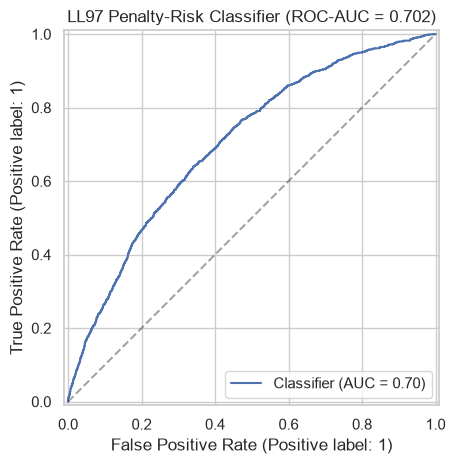

In [31]:
# =============================================================================
# STEP 8 — CLASSIFYING LL97 PENALTY RISK (CLASSIFICATION)
# Predict whether a building exceeds its LL97 limit, from STRUCTURAL features only.
# Self-contained: rebuilds ll97_limit on model_df; depends only on Step 7a's
# model_df, cat_features, num_features, preprocess.
# =============================================================================
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import (roc_auc_score, classification_report,
                             confusion_matrix, RocCurveDisplay)
from xgboost import XGBClassifier
import matplotlib.pyplot as plt

# --- Rebuild the LL97 limit directly on model_df (don't rely on Step 6's frame)
LL97_LIMITS = {
    "Multifamily Housing": 6.75, "Office": 8.46, "Hotel": 9.87,
    "K-12 School": 7.58, "College/University": 7.58, "Retail Store": 11.81,
    "Senior Living Community": 10.74, "Manufacturing/Industrial Plant": 5.74,
    "Non-Refrigerated Warehouse": 5.74, "Self-Storage Facility": 5.74,
    "Worship Facility": 7.58, "Mixed Use Property": 8.46, "Other": 8.46,
}
model_df = model_df.copy()
model_df["ll97_limit"] = model_df["property_type_grp"].map(LL97_LIMITS)
model_df = model_df.dropna(subset=["ll97_limit"])

# --- Target + features (STRUCTURAL only — leakage guard) -----------------------
# over_ll97 is derived from ghg_intensity, so intensity/EUI/energy must NOT be
# features. We reuse the same structural design matrix as Step 7.
y_clf = (model_df["ghg_intensity"] > model_df["ll97_limit"]).astype(int)
Xc = model_df[cat_features + num_features]

print("Rows:", len(model_df), "| Class balance (share over limit):", round(y_clf.mean(), 3))

Xc_tr, Xc_te, yc_tr, yc_te = train_test_split(
    Xc, y_clf, test_size=0.2, random_state=42, stratify=y_clf)

# scale_pos_weight handles the imbalance for XGBoost
spw = (yc_tr == 0).sum() / max((yc_tr == 1).sum(), 1)

clf_models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight="balanced"),
    "Random Forest": RandomForestClassifier(
        n_estimators=150, max_depth=12, n_jobs=-1,
        random_state=42, class_weight="balanced"),
    "XGBoost": XGBClassifier(
        n_estimators=300, learning_rate=0.05, max_depth=6,
        subsample=0.8, colsample_bytree=0.8, n_jobs=-1,
        random_state=42, scale_pos_weight=spw),
}

# --- Compare models by ROC-AUC -------------------------------------------------
print("\nClassification model comparison (predicting LL97 exceedance):\n")
for name, model in clf_models.items():
    pipe = Pipeline([("prep", preprocess), ("model", model)])
    pipe.fit(Xc_tr, yc_tr)
    proba = pipe.predict_proba(Xc_te)[:, 1]
    print(f"  {name:22s} ROC-AUC = {roc_auc_score(yc_te, proba):.3f}")

# --- Detailed report + ROC curve for the best model (XGBoost) ------------------
best_clf = Pipeline([("prep", preprocess), ("model", clf_models["XGBoost"])]).fit(Xc_tr, yc_tr)
proba = best_clf.predict_proba(Xc_te)[:, 1]
pred = (proba >= 0.5).astype(int)

print("\nXGBoost classification report:\n")
print(classification_report(yc_te, pred, target_names=["Compliant", "Over limit"]))
print("Confusion matrix (rows = actual, cols = predicted):")
print(confusion_matrix(yc_te, pred))

RocCurveDisplay.from_predictions(yc_te, proba)
plt.plot([0, 1], [0, 1], "k--", alpha=0.4)
plt.title(f"LL97 Penalty-Risk Classifier (ROC-AUC = {roc_auc_score(yc_te, proba):.3f})")
plt.tight_layout()
plt.savefig("fig_ll97_roc.png", dpi=150)
plt.show()

### Machine learning: predicting emissions and penalty risk

Two supervised models were trained on **structural features only** (property type,
floor area, building age, borough), deliberately excluding energy and emissions
metrics that mechanically determine the targets — a strict guard against feature
leakage.

**Regression (predicting emissions intensity).** Gradient boosting achieved a
cross-validated R² of ~0.11 (± 0.03). Structural characteristics explain only a
small share of the variation in emissions intensity; the majority is driven by
operational factors — fuel choice, actual occupancy, and equipment — not captured
in structural data. This is itself the finding: a building's emissions are
determined more by how it is operated than by what it structurally is.

**Classification (predicting LL97 exceedance).** Predicting whether a building
exceeds its LL97 limit was substantially more tractable (ROC-AUC ≈ 0.70) than
predicting its exact intensity. The model recovers 61% of at-risk buildings from
structure alone, before any energy data is available. Precision was traded for
recall (via class weighting) on the reasoning that, for a screening tool, missing
an at-risk building is costlier than a false alarm.

**The instructive contrast:** structure poorly predicts the emissions *value*
(R² 0.11) yet usefully predicts the pass/fail *outcome* (AUC 0.70) — because
classification only requires placing a building on the correct side of a
threshold, not estimating its precise emissions. This distinction between
regression and classification difficulty, on the same underlying data, is the
core analytical takeaway.